# Module 4 — The FUR Regulon: Literature to Motif

**Lab context:** *E. coli* K-12 | bowtie2 | MEME Suite | Biopython | FUR transcription factor

---

This module connects a published dataset to a motif analysis pipeline:

1. **Understanding the literature** — read a real ChIP-exo paper and extract biological context.
2. **RNA-seq paired-end alignment** — the foundational read-alignment step (extends Module 3), applied to the study's transcriptome data.
3. **Motif discovery with MEME** — given a set of genomic sequences, MEME finds overrepresented patterns.
4. **Sequence extraction with Biopython** — pull binding-site sequences from the *E. coli* K-12 genome by coordinate.
5. **TSS distance analysis** — compute distances between binding sites and transcription start sites.

---

**Learning objectives:**
- Understand a real ChIP-exo study and the data it produced
- Use Biopython to extract genomic sequences by coordinate from a public dataset
- Run MEME and interpret motif output (E-value, logo shape)
- Download and align **paired-end RNA-seq** reads with bowtie2, and turn them into a GFF track
- Compute TSS distances as a downstream regulatory analysis


## Background: Transcription Factors, FUR, and Motifs

### What is a transcription factor?

A **transcription factor (TF)** is a protein that binds to specific short DNA sequences near a gene and controls whether that gene gets expressed. Think of it as a light switch wired into the chromosome: when the TF binds, it turns the gene on (or off). Bacteria like *E. coli* use hundreds of TFs to respond to changing conditions — temperature, nutrients, stress.

### What is FUR?

**FUR** (Ferric Uptake Regulator) is one of the most-studied TFs in *E. coli*. Its job is to sense how much iron is available in the cell and adjust gene expression accordingly:

- **Iron-replete (plenty of iron):** FUR binds its target sites and *represses* iron-uptake genes (no need to import more iron)
- **Iron-depleted (low iron):** FUR releases its targets, allowing iron-uptake genes to be expressed

Iron is essential for most cellular processes but toxic in excess — FUR is the cell's main iron thermostat. It controls roughly 90 genes in *E. coli*.

### What is a regulon?

A **regulon** is the complete set of genes controlled by one TF. The FUR regulon = all genes whose expression is directly regulated by FUR binding. Mapping a regulon requires knowing *where* FUR binds — which is exactly what ChIP-exo (Module 3) measures.

### What is a DNA binding motif?

When a TF binds DNA, it doesn't land randomly — it recognizes a specific short sequence pattern, typically 15–20 bp. This pattern is the TF's **binding motif**. For FUR it's called the **Fur box**. If you look at all the genomic sites where FUR binds, you expect to find the same short sequence pattern repeated at each one.

**MEME** is the tool that discovers this pattern automatically: it takes a set of sequences (your ChIP-exo peaks) and finds the motif that appears more often than chance would predict.

---

## 1. The FUR Regulon — Seo et al. 2014

The FUR binding site data used in this module comes from a real published study:

> **Seo SW, Kim D, Latif H, O'Brien EJ, Szubin R, Palsson BO (2014)** — *Deciphering Fur transcriptional regulatory network highlights its complex role beyond iron metabolism in Escherichia coli* — ***Nature Communications*** 5:4910.
> PMID: 25222563 | PMC: https://pmc.ncbi.nlm.nih.gov/articles/PMC4167408/ | DOI: 10.1038/ncomms5910 | GEO: **GSE54901**

The study used ChIP-exo to map Fur-binding sites genome-wide across different iron conditions.

**Two different things live in two different places — this matters for the exercises:**
- **Raw ChIP-exo signal** is deposited at GEO (**GSE54901**), as per-base *coverage tracks* (one row per genomic position). This is what you align to and visualize — it is **not** a list of binding sites.
- **The discrete binding-site coordinates** (the 144 called peaks, with their target genes and signal strengths) are in the paper's **Supplementary Data** table (an Excel file), *not* on GEO. This table is the input to your MEME analysis in Exercise 5.


### Exercise 1 — Understand the paper and its data

Read Seo et al. 2014 (PMC4167408) — or use Claude Code to help you understand it — and write a **3-sentence summary** in the cell below covering:
- What experiment was done, in what organism, and under what conditions
- How many FUR binding sites were identified and what regulatory modes (categories) were described
- Where the discrete binding-site coordinates are found (which supplementary table), and — separately — what kind of data GEO GSE54901 actually holds

In Exercise 5 you will download the **supplementary binding-site table** from the paper and use its coordinates as the input to motif discovery.


> **Answer**
>
> *Your 3-sentence summary here.*

> 배경: 기존에는 철 결합 상태의 Fur가 전사를 억제하는 방식으로 알려져 있었으나, 철의 유무에 따른 실제 in vivo 상 결합영역 및 정확한 전사조절 메커니즘을 밝히기 위해 연구를 하였다.


> 실험 방법: 대장균(E.coli)을 철 풍부 조건과 철 결핍 조건에서 배양한 후, ChIP-exo로 Fur와 RNAP의 결합 위치를 찾아내고 RNA-seq 데이터를 결합하여 직접 조절 대상 유전자와 각 조절 모드를 규명했다.(3가지의 mode, 아래 문장에서 설명)


> 결론: 분석 결과 대장균 내 총 81개 유전자가 기존에 알려진 holo-Fur 억제(HR)뿐 아니라 holo-Fur 활성화(HA) 및 apo-Fur 활성화(AA) 모드로 직접 조절됨을 확인하여 Fur가 단순 철 억제를 넘어 DNA 합성, 에너지 대사, 바이오필름 형성 등 세포의 주요 생리 과정을 조절함을 밝혔다.

## 2. RNA-seq: Paired-End Alignment with `bowtie2`

So far you've worked with **ChIP-exo** data (single-end). The same Fur study also produced **RNA-seq** data — a *second data type* and your first **paired-end** alignment.

Paired-end sequencing reads **both ends** of each DNA fragment, producing two FASTQ files per sample (`_1` = R1, `_2` = R2). `bowtie2` aligns them together (`-1`/`-2`), using the known fragment-size range to place reads more accurately than single-end. In this section you'll download an RNA-seq sample, align it paired-end, and turn it into a GFF — the same pipeline shape as Module 3, but for a new data type.

**Data:** the RNA-seq sub-series of the Fur study is **GEO GSE54900** (same paper, *Nature Communications* 5:4910). In the original lab workflow the paired-end sample `SRR1168133` was aligned with `bowtie2 --very-fast -X 1000 -3 3` (paired-end), then sorted and converted to GFF with `makegff.py`.


### Exercise 2 — Run a paired-end RNA-seq alignment

**Step 1 — Get a paired-end RNA-seq sample.**
Use Claude Code to navigate to the RNA-seq series and pick one paired-end sample:
```
https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE54900
```
Ask Claude Code to help you:
1. Find a **paired-end** RNA-seq run in GSE54900 and get its SRR accession.
2. Download it with `fastq-dump --split-files <SRR>` (or `fasterq-dump`) — paired-end gives you **two** files, `<SRR>_1.fastq` and `<SRR>_2.fastq`.

**Step 2 — Align paired-end.**
Reuse the *E. coli* K-12 bowtie2 index you built in Module 3. Run a **paired-end** alignment — note the `-1`/`-2` inputs (not a single `-U`):
```bash
bowtie2 --very-fast -X 1000 -3 3 -p 2 \
    -x <index_prefix> \
    -1 <SRR>_1.fastq -2 <SRR>_2.fastq \
    -S <SRR>.sam
```
Then `samtools view -bS` → `samtools sort` → `samtools index`, exactly as in Module 3.

**Step 3 — Make a GFF for the RNA-seq data.**
Run your `makegff.py` from Module 3 on the sorted BAM to produce a coverage GFF (this is RNA-seq signal, so both strands are meaningful):
```bash
python makegff.py --separate_strand <SRR>.sorted.bam rnaseq.gff
```
This GFF can be loaded into **MetaScope** alongside the gene annotation to visualize transcription — the same way you visualize the ChIP-exo track.

**Step 4 — Explain the flags.** In the Answer cell, write a **one-sentence explanation for each** flag below (focus on *why*, not just mechanics), drawing on what you saw when you ran the alignment:
- `-X 1000` (maximum fragment/insert size — a paired-end-only flag)
- `-3 3` (3′ trimming)
- `--no-mixed` and `--no-discordant` (paired-end concordance)

Also answer: **why is `-X` meaningless for the single-end ChIP-exo alignment in Module 3, but important here?** And: what would go wrong downstream if you forgot `--no-discordant`?

> **Single-end vs paired-end:** Module 3 aligned ChIP-exo reads with a single `-U` input. Here you use `-1`/`-2`. If you accidentally pass paired files to `-U`, bowtie2 treats them as unpaired and every `-X`/concordance flag is silently ignored — a common and quiet mistake.

Write your working pipeline in the code cell below (or run it in the terminal and paste the commands here).


In [ ]:
%%bash
# Paired-end RNA-seq pipeline (GSE54900) — fill in the commands after generating them with
# Claude Code. This is a bash cell: the FIRST line MUST be %%bash, or Jupyter will try to
# run these shell commands as Python and fail with a SyntaxError.
# Run from the repo root (the notebook's working directory); reads/outputs live in data/reference/.

# Step 1: Download the paired-end RNA-seq sample (fastq-dump --split-files -> _1.fastq / _2.fastq)
SRR=SRR1168133
if [ ! -f ../data/reference/${SRR}.sra ]; then
    curl --insecure -L -o ../data/reference/${SRR}.sra "https://sra-pub-run-odp.s3.amazonaws.com/sra/${SRR}/${SRR}"
fi
if [ ! -f ../data/reference/${SRR}_1.fastq ] || [ ! -f ../data/reference/${SRR}_2.fastq ]; then
    fastq-dump --split-files --outdir ../data/reference/ ../data/reference/${SRR}.sra
fi

# Step 2: Align paired-end reads, reusing the Module 3 bowtie2 index (-1/-2, not -U)
if [ ! -f rnaseq.sam ]; then
    bowtie2 --very-fast -X 1000 -3 3 -p 2 --no-mixed --no-discordant \
        -x ../data/reference/NC_000913.3 \
        -1 ../data/reference/${SRR}_1.fastq -2 ../data/reference/${SRR}_2.fastq \
        -S rnaseq.sam
fi

# flag 설명
# --very-fast : 속도 우선 preset (하이퍼파라미터 대신 개발자가 미리 지정해놓은 최적값. 민감도 낮아짐.)
# -X 1000     : 두 mate 사이 최대 fragment 크기 1000bp (paired-end 전용)
# -3 3        : read 3' 끝 3bp 트리밍 
# -p 2        : 스레드 수 
# --no-mixed  : mate 짝이 없으면 개별 단일 정렬 금지 (fallback 금지)
# --no-discordant : 불일치 쌍을 결과에서 제외 (concordant만 남김)
# -x          : Module 3에서 만든 index 그대로 재사용
# -1 / -2     : 각각 paired-end 두 mate 파일
# -S          : SAM 출력 경로

# Step 3: SAM -> sorted, indexed BAM (samtools view / sort / index)
if [ ! -f rnaseq_sorted.bam ]; then
    samtools view -bS rnaseq.sam > rnaseq.bam
    # -b: BAM(바이너리)으로 출력, -S: 입력이 SAM임을 명시 (대문자 S! 소문자 -bs는 subsampling 옵션이라 에러남)

    samtools sort -m 200M -o rnaseq_sorted.bam rnaseq.bam
    # -m 200M: 스레드 1개당 메모리 200M로 제한 (이 단계가 실제로 두 번 "Terminated"로 죽었던 곳이라 여기만 가볍게 유지)
    # -o: 출력 파일 경로

    samtools index rnaseq_sorted.bam
    # 정렬된 BAM에 .bai 인덱스 생성 (빠른 구간 조회를 위해 필요)
fi

# Step 4: Run the lab's provided root makegff.py on the sorted BAM (RNA-seq -> --separate_strand --flip --log_scale)
python ../makegff.py --separate_strand --flip --log_scale rnaseq_sorted.bam rnaseq.gff
# --separate_strand: +/- strand를 별도 트랙으로 분리해서 기록(feature 이름 다르게 설정)
# --flip: 1st-strand cDNA만 시퀀싱하므로, 장비가 5' -> 3' 방향으로 읽어낸 Read는 원래 mRNA의 역상보(Antisense) 서열. 따라서 Read를 역상보로 보정.
# --log_scale: score = log2(count). genome 전체에 rRNA operon 등으로 인한 outlier가 있어 log_scale로 스케일링. 

> **Answer**
>
> **`-X 1000`:**
> paired end에서는 각 read를 양끝에서 읽는데, 이 때 그 쌍을 mate 라고 하며 유효한 mate는 그 read fragment의 길이가 1000bp 이내여야 한다.
>
> **`-3 3`:**
> read의 3' end에서 3bp는 trimming 하여 시퀀싱 품질을 유지한다.
>
> **`--no-mixed` / `--no-discordant`:**
> mate 쌍이 존재하지 않으면 single end 처럼 정렬하는 것을 금지한다. (fallback 금지)
>
> **Why `-X` matters here but not in Module 3 (single-end):**
> -X는 두 mate 사이의 거리라는 개념이 있어야 성립하는 옵션이다. 따라서 module 3에서는 필요가 없다.
>
> **What goes wrong without `--no-discordant`:**
> 이것을 빼먹으면 makegff.py 의 coverage 로직에서 is_proper_pair인 read1은 두 mate 사이 전체 insert 구간을 coverage를 채운다. discordant 쌍이 섞여 들어오면 이상하게 매핑된 read 때문에 엉뚱한 위치에 잘못된 coverage 가 생겨서 rnaseq.gff의 발현량 신호가 왜곡될 수 있다.
>
> **Why the RNA-seq `makegff.py` needs `--flip` but the ChIP-exo one didn't:**
> RNA-seq 라이브러리 제작 시 역방향 가닥(Antisense strand)을 센서싱하여 읽으므로 정방향 Strand(Sense)와 맞추기 위해 --flip(Reverse Complement) 옵션이 필요하다. 반면, ChIP-exo는 DNA 자체를 직접 시퀀싱하므로 5'->3' 읽기 방향과 매핑된 Genomic Strand가 그대로 일치하여 --flip할 필요 없다.

## 3. How MEME Works

### What problem does MEME solve?

You have 90 genomic sequences — one around each FUR binding site. If FUR binds a specific sequence pattern (the Fur box), that pattern should appear in most of your sequences. But you don't know in advance *what* the pattern looks like or exactly *where* in each sequence it sits.

**MEME** (Multiple Em for Motif Elicitation) finds overrepresented sequence patterns in a set of input sequences without knowing what to look for. It uses an algorithm called Expectation-Maximization (EM) to iteratively refine a motif model until it fits the data as well as possible.

### What is an E-value?

The **E-value** answers: *"How many times would I expect to find a motif this good by random chance in a dataset this size?"*

- E-value of 10⁻²⁰ → extremely unlikely by chance → strong, real motif
- E-value of 1.5 → you'd expect to see this pattern 1–2 times by chance → likely noise

For a real TF binding motif like the Fur box, expect E-values well below 10⁻¹⁰. If your top motif has an E-value above 0.01, something may be wrong with your input sequences (wrong coordinates, wrong organism, mixed conditions).

Use Claude Code to understand how the EM algorithm works and what the E-value measures before running MEME.

### Exercise 3 — Understand MEME in your own words

Use Claude Code to explore the MEME algorithm and E-value interpretation. Then write a **3-sentence summary in your own words** — not copied from Claude's output, but re-stated in your own understanding.

> Focus on: what problem EM is solving, what E-value measures, and why motif width matters.

> **Answer**
>
> *Your 3-sentence summary here.*
> MEME은 EM 알고리즘을 써서 모티프를 찾아내며 다음의 2,3 step을 반복하며 최적의 값을 찾는데 먼저 초기화에선 모티프 확률표(PWM)을 무작위로 만든다.
    > - E-step (expectation): 초기화 때 만든 무작위 확률표를 가지고 모든 서열을 다 훑으면서 여기가 모티프일 확률을 계산 
    > - M-step (maximization): 방금 계산한 확률들을 가중치로 삼아서, 모티프 모양을 다시 더 정확하게 추정.   

> E-value: 우연히(By Chance) 발생할 예상 횟수, 작을수록 좋다. 

### Exercise 4 — Conceptual prediction (answer before asking Claude)

**Without asking Claude Code first:** predict what the MEME output would look like for each of these two inputs:

(a) 10 **random** 200 bp genomic sequences from *E. coli* K-12  
(b) 10 **real FUR binding site** sequences (±50 bp around known sites)

For each case, predict: approximate E-value range, whether a clear motif logo would appear, and what width you would expect.

Write your prediction below. Then verify your reasoning with Claude Code and note where you were right or wrong.

*Your prediction here (before checking with Claude Code).*
> (a) 10 random 200bp genomic sequences from E.coli K-12
> E-value가 클 것이며 서열 간 공통 염기가 없어 정보량이 낮아 모든 motif logo 그래프를 보면 모든 염기가 작고 겹칠 것이다. 또한 생물학적 모티프가 없으므로 특정 길이로 수렴하지 않고 알고리즘이 임의로 최적화한 범위가 설정될 것이다. 
>
> (b) E-value가 굉장히 작을 것이며 FUR box의 보존된 염기 부위에서 높은 정보량을 가져 motif logo 그래프를 보면 해당 위치의 염기 글자가 크게 솟아오를 것이다. 모티프의 예상 길이는 단백질이 실제 결합하는 Fur box의 서열 길이랑 비슷할 것이다.   
---

*Verification notes (after checking with Claude Code):*
> (a) 검증: `NC_000913.2.fasta`에서 무작위 위치 10곳을 골라 200bp씩 잘라(`random_sites_for_meme.fasta`) 실제로 동일한 MEME 커맨드(`-dna -mod zoops -minw 15 -maxw 25 -nmotifs 3 -revcomp`)로 돌려봤다. 
> 결과: 3개 모티프의 E-value가 각각 45, 140, 1100으로 모두 유의하지 않았고(p-value = 0.01), 컨센서스 서열도 `MWGBCGCYGTTTCVSBTCDK`처럼 IUPAC 모호 코드(M/W/B/V/D/H)가 많아 특정 염기를 추출하기 힘들었다. 폭도 20bp/19bp/15bp로 값이 수렴하지 않았다. 
>
> (b) 검증: Exercise 5, 6에서 143개 real Fur binding site로 같은 MEME을 돌려봤다. 
> 결과: 최상위 모티프의 E-value는 2.3×10⁻¹⁹¹ (141/143 사이트에서 발견), 폭은 24bp로 수렴했고, 핵심 구간(`ATTCTCA` 계열)에서 위치별 우세 염기 확률이 0.66~1.00으로 뚜렷하게 올랐다.  

## 4. Extracting Sequences with Biopython

The Fur-binding site coordinates come from the **Supplementary Data table of Seo et al. 2014** (an Excel file you download from the paper in Exercise 5), which lists each site's `ChIP-exo Start` / `ChIP-exo End`. Use Biopython to extract DNA sequences from the *E. coli* K-12 reference FASTA at those coordinates. Handle strand correctly — reverse-complement sequences on the minus strand.


### Exercise 5 — Fetch the data and write the sequence extraction script

**Step 1 — Get the binding-site table with Claude Code:**
The discrete Fur binding sites are in the **Supplementary Data** of the Nature Communications paper, not on GEO. Give Claude Code the article page and ask it to locate and download the supplementary table:

```
https://www.nature.com/articles/ncomms5910
```

Ask Claude Code to:
1. Find the **Supplementary Data** file that contains the Fur ChIP-exo **binding sites** (target gene, `ChIP-exo Start`, `ChIP-exo End`, binding condition, S/N ratio) and download it into `data/reference/`. *(It is an Excel `.xlsx` file — the same one used in the original lab tutorial.)*
2. Download the *E. coli* K-12 reference FASTA into `data/reference/NC_000913.fasta` (same file as Module 3 — skip if already present).

**Step 2 — Read the table.** It has a title row above the real header, so read it with the header on the **second** row:
```python
import pandas as pd
df = pd.read_excel("data/reference/<supplementary_file>.xlsx", header=1)
df = df.dropna(subset=["Peak"])          # keep rows that are actual binding sites
```
Columns include: `Transcription Unit`, `Peak` (a peak **ID label** like `P1`, `P2` — *not* a score), `ChIP-exo Start`, `ChIP-exo End`, `Binding Condition` (`R` = iron-replete, `S` = iron-depleted, `R/S` = both), `S/N ratio` and `Significance (p-value)` (these are the strength/score fields), and `Distance to TSS`. Filter to the **iron-replete** sites with `Binding Condition` containing `R`.

**Step 3 — Write a Biopython script that:**
1. Reads the binding-site coordinates from the table (iron-replete sites).
2. Loads the reference FASTA.
3. Extracts sequences ±50 bp around each binding site center (center = midpoint of `ChIP-exo Start`/`End`).
4. Handles strand correctly if a strand is available (reverse complement for `-`).
5. Writes a FASTA file (`data/reference/fur_sites_for_meme.fasta`) ready for MEME input.

> **Coordinate convention warning:** the table's coordinates are **1-based**. Python string slicing is **0-based**. Off-by-one errors here silently shift every extracted sequence.

> **Genome-version note:** the paper's coordinates were called on the *E. coli* K-12 MG1655 genome. Extract from a reference FASTA consistent with those coordinates, and sanity-check a couple of sequences (e.g. does a known Fur site contain a recognizable Fur box?) before trusting all of them.

Run the script and confirm the output FASTA has about one sequence per binding site before proceeding. For reference, the table has **144** sites total; **143** are bound under the iron-replete condition (82 labelled `R` = iron-replete only, plus 61 labelled `R/S` = bound in both conditions), and only 1 is `S`-only.

Write the final working script in the code cell below.


> **Explain it:** after your code runs, write 1–2 sentences on *how it works and why Claude chose that approach*. You should be able to defend every line — if you can't explain it, you don't yet understand it.

explain it에 대한 답변: 이 스크립트는 논문의 Supplementary Data 1 파일에서 철 충분 조건에 해당하는 143개의 Fur 결합 부위(R 또는 R/S)를 필터링한다. 이후 각 피크의 중앙점을 계산한 뒤, 파이썬의 0-based 인덱싱 방식을 적용하여 NC_000913.2 게놈 서열에서 중앙점 기준 양측으로 50bp 구간을 자른다. 
supplementary 파일의 데이터 표에 strand 정보가 없어 모든 가닥을 +라고 생각하였으나, MEME은 기본적으로 양쪽 가닥을 모두 탐색하므로 분석에 문제가 없다.

In [ ]:
import pandas as pd
from Bio import SeqIO

df = pd.read_excel("../data/reference/ncomms5910_supp_data1.xlsx", header=1) # 엑셀 표에서 header=1, 2번째 행을 df의 컬럼명으로 지정.
df = df.dropna(subset=["Peak"])  # peak 컬럼의 결측치 제거
df = df[df["Binding Conditiona"].astype(str).str.contains("R")]  # Binding Conditiona' 컬럼에서 철 충분 조건인 'R'(또는 R/S)만 필터링.

record = SeqIO.read("../data/reference/NC_000913.2.fasta", "fasta") # 논문의 대장균 참조 FASTA 파일을 읽기.
genome = str(record.seq) # 읽어온 데이터에서 순수한 DNA 서열만 추출하여 genome 변수에 저장.

FLANK = 50 # 결합 부위를 중앙점 기준 양옆 50bp로 설정.
records = [] # 자른 서열 데이터(이름, 시작좌표, 끝좌표, DNA서열)를 모아둘 리스트.
for _, row in df.iterrows(): # 필터링된 df 순회
    start = int(row["ChIP-exo Start"]) # chip 데이터에서 start 위치 찾기.
    end = int(row["ChIP-exo End"])
    center = (start + end) // 2 # 중앙점 계산
    win_start = center - FLANK # 중앙점에서 frank만큼 양측 더하고 빼주기
    win_end = center + FLANK

    seq = genome[win_start - 1 : win_end] # 0-based 인덱스로 변환

    tu = row["Transcription Unit"] # 해당 피크와 연결된 전사 단위(TU) 이름을 가져옴.
    name = f"{row['Peak']}_{tu}" if pd.notna(tu) else row["Peak"] # TU 이름이 존재하면 "피크ID_TU이름"으로 없으면 피크ID만으로 서열의 고유 이름 지정
    records.append((name, win_start, win_end, seq)) # 생성한 서열 이름, 시작, 끝 위치, 잘라낸 서열을 튜플로 묶어 리스트에 추가

with open("../data/reference/fur_sites_for_meme.fasta", "w") as out:
    for name, win_start, win_end, seq in records:
        out.write(f">{name} NC_000913.2:{win_start}-{win_end}\n{seq}\n")

print(f"{len(records)} sequences written to data/reference/fur_sites_for_meme.fasta") # 총 몇 개의 서열이 FASTA로 생성됐는지 개수 확인

## 5. Running MEME

MEME is a command-line tool. The basic invocation is:

```bash
meme input.fasta -dna -oc output_dir -mod zoops -minw 15 -maxw 25 -nmotifs 3
```

Use **Claude Code plan mode** to generate the full command with the flags appropriate for your FUR binding site dataset. Make sure you understand each flag before running.

> **Think first:** FUR binds double-stranded DNA, so a binding motif can appear on either strand. Which MEME flag accounts for this? Write your answer before generating the command.
> Answer: -dna (또는 -revcomp) 옵션이다. MEME에서 -dna 플래그를 주면 Reverse Complement 가닥까지 다 훑어서 모티프를 찾아준다.

In [1]:
%%bash

export PATH="/opt/meme/bin:$PATH"

meme ../data/reference/fur_sites_for_meme.fasta \
    -dna \
    -oc ../data/reference/meme_out \
    -mod zoops \
    -minw 15 -maxw 25 \
    -nmotifs 3 \
    -revcomp

The output directory '../data/reference/meme_out' already exists.
Its contents will be overwritten.
BACKGROUND: using background model of order 0
PRIMARY (classic): n 143 p0 143 p1 0 p2 0
SEQUENCE GROUP USAGE-- Starts/EM: p0; Trim: p0; pvalue: p0; nsites: p0,p1,p2
SEEDS: maxwords 14443 highwater mark: seq 143 pos 86
Initializing the motif probability tables for 2 to 143 sites...


nsites = 143
Done initializing.

seqs=   143, min_w= 101, max_w=  101, total_size=    14443

motif=1
SEED DEPTHS: 2 4 8 16 32 64 128 143
SEED WIDTHS: 15 21 25
em: w=  25, psites= 143, iter=  40 Warning: Cannot convert EPS file to PNG as no install of Image Magick or Ghostscript is usable.

motif=2
SEED DEPTHS: 2 4 8 16 32 64 128 143
SEED WIDTHS: 15 21 25
em: w=  25, psites= 143, iter=  40 Warning: Cannot convert EPS file to PNG as no install of Image Magick or Ghostscript is usable.

motif=3
SEED DEPTHS: 2 4 8 16 32 64 128 143
SEED WIDTHS: 15 21 25
em: w=  25, psites= 143, iter=  40 Warning: Cannot convert EPS file to PNG as no install of Image Magick or Ghostscript is usable.



### Exercise 6 — Interpret your MEME results

After running MEME:
1. Use Claude Code to help you read the `meme.txt` or `meme.html` output.
2. Then write your **own assessment** — do not just copy Claude's interpretation.

Address all three of the following:
- **E-value:** Is the top motif statistically significant? What does the E-value tell you?
- **Motif logo:** Does the shape match what you expect for a FUR binding site (the "Fur box")? Which positions are most conserved?
- **Biological meaning:** Given your background from Exercise 1 (the published FUR regulon), is this result consistent with the literature? Why or why not?

Write your assessment in the markdown cell below.

> **Answer**
>
> [MEME 1]
>
> **1) E-value:** 2.3 x 10⁻¹⁹¹, 143개 서열 중 141개 발견 (sites = 141)
>
> **2) Logo 모양:** MEME이 뽑아낸 24bp 너비의 시드 중, 각 위치별 최고 확률 염기를 뽑아보면 다음과 같다.

| 위치 | 우세 염기 | 확률 |
|---|---|---|
| 10 | A | 0.66 |
| 11 | T | 0.91 |
| 12 | T | 1.00 |
| 13 | C | 0.66 |
| 14 | T | 0.91 |
| 15 | C | 0.94 |
| 16 | A | 0.97 |

> **3) 생물학적 의미:** 중앙 보존 구간(ATTCTCA 계열)은 논문(Fig. 4b)에서 제시한 Fur box consensus의 palindrome 핵심부(TGATAATnATTATCA 계열, AT 풍부)와 같은 성격을 보인다. 정확히 논문 컨센서스와 안 맞은 이유는 조절 모드(HR/HA/AA)를 안 나누고 다 합쳐서 분석했기 때문이다.

## 6. TSS Distance Analysis

A common downstream analysis computes the distance between each transcription factor binding site and the nearest transcription start site (TSS).

### Exercise 7 — TSS distance script

Two data sources are available for this analysis:
- **Binding sites:** the Fur binding-site table you downloaded in Exercise 5 (`ChIP-exo Start`/`End` per site). The table also contains a `Distance to TSS` column for a subset of sites — you can use this to **cross-check** your own computation.
- **Gene annotation:** `data/reference/ec_annotation_20100903_DHK_cSRNA_with_ortho.gff` (pre-provided — lab *E. coli* K-12 gene annotation; all rows are `gene` features, so a TSS must be derived from each gene's start/strand: gene start for `+`, gene end for `-`)

Use Claude Code to generate a Python script that:
1. Reads the binding-site coordinates and the annotation GFF.
2. For each Fur binding site, computes the distance to the nearest TSS.

> **Coordinate-space warning:** the binding-site table has no chromosome column — its coordinates are positions on the *E. coli* K-12 genome. The annotation GFF uses seqname `NC_000913`, while the reference FASTA you downloaded is `NC_000913.3`. When you compare binding-site positions to gene positions, make sure both are in the **same coordinate space** (same genome build) — otherwise distances will be systematically off, silently. This is a good place to run a quick sanity check (does a known site land near its known target gene?).
3. Reports: minimum distance, median distance, and fraction of binding sites within 500 bp of a TSS.
4. (Optional) Plots the distance distribution as a histogram.

Write the final working script in the code cell below.

> **Cross-check:** compare your computed distances against the paper's `Distance to TSS` column for the sites that have one. If they disagree by a constant offset, you likely have an off-by-one or a genome-version mismatch.
> ANSWER: diff = df.loc[mask, "dist_to_tss"] - paper_dist[mask]에서 계산하여 비교했다. 

> **Biological framing:** Based on Exercise 1 (the Seo et al. 2014 paper), what distance distribution do you expect? Write your prediction as a comment at the top of the script.
> ANSWER: 코드 맨 위 주석으로 적음. 

> **Explain it:** after your code runs, write 1–2 sentences on *how it works and why Claude chose that approach*. You should be able to defend every line — if you can't explain it, you don't yet understand it.

Explain it에 대한 답: 본 코드는 GFF annotation 과의 좌표 일치성을 유지하기 위해 결합 부위 좌표를 `NC_000913.2`에서 `NC_000913.3`으로 변환(Liftover)하고, 가닥 방향(`+` 가닥은 start, `-` 가닥은 end)에 맞춰 TSS 위치를 추출했다. 이후 이진 탐색(`np.searchsorted`)을 활용해 각 사이트에서 가장 가까운 TSS까지의 최단 거리를 계산하여 게놈 버전 간의 정확도 확보와 빠른 거리 계산 성능을 동시에 달성했다.

결합 부위 개수: 143
최소 거리: 5 bp
중앙값 거리: 287.0 bp
500bp 이내 비율: 71.3%

교차검증 대상: 69개 사이트, 차이(절대값) 중앙값 = 176bp


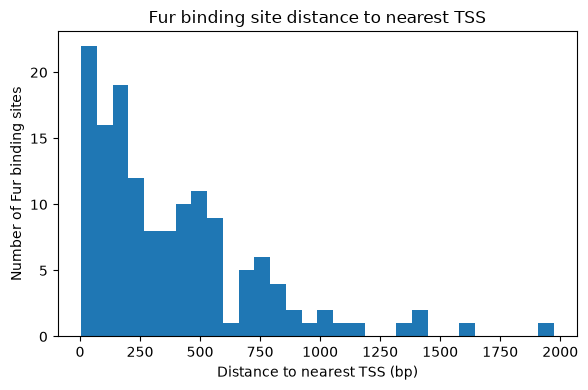

In [ ]:
# TSS distance analysis script.
# Prediction (write before running): ...

# 예측: FUR은 promoter/operator에 결합해 전사를 억제/활성화하는 TF이므로, regulatory site들이 TSS와 아주 가까울(수십~수백bp) 것으로 예상. 
# 다만 논문에서 밝혔듯 결합 부위의 약 46%는 intragenic/non-regulatory 영역에 있어 TSS와 상관없이 멀리 떨어져 있을 수 있으므로, 전체 분포는 0에 가까운 뾰족한 봉우리 + 먼 거리의 긴 꼬리의 봉우리 형태로 예상.

import numpy as np # numpy 모듈 불러오기
import pandas as pd # pandas 모듈 불러오기(csv/엑셀 테이블 다루기 위해)
import matplotlib.pyplot as plt # 히스토그램 그려야하므로 matplotlib 불러오기

# 1) iron-replete binding site 143개 로드
df = pd.read_excel("../data/reference/ncomms5910_supp_data1.xlsx", header=1) # 논문의 엑셀 파일을 읽어 df에 저장. header=1(두 번째 줄)을 column 이름으로 사용. 
df = df.dropna(subset=["Peak"]) # peak 열 값의 NaN 제거. 
df = df[df["Binding Conditiona"].astype(str).str.contains("R")].copy() # binding conditiona 열을 문자열로 변환 후, 철분 풍부 조건 'R' 을 포함하는 행만 남김. .copy() 사용해 복사본으로 생성.

# 2) binding-site 표는 논문 Methods에 명시된 NC_000913.2, annotation GFF는 NC_000913.3 기준이므로 아래 offset 표로 .2 -> .3 좌표로 변환.
LIFT_BREAKPOINTS = [
    (257907, 776), (547835, 777), (1298721, 1976),
    (2171386, 1978), (3558477, 1977),
]
def lift_v2_to_v3(pos):
    offset = 0
    for breakpoint, cum_offset in LIFT_BREAKPOINTS:
        if pos >= breakpoint:
            offset = cum_offset
        else:
            break
    return pos + offset

df["center_v2"] = ((df["ChIP-exo Start"] + df["ChIP-exo End"]) // 2).astype(int) # ChIP-exo start와 end의 평균을 중심점으로 설정.
df["center_v3"] = df["center_v2"].apply(lift_v2_to_v3)  # 위의 좌표 변환 함수 lift_v2_to_v3 이용해 센터값 V3에 맞게 변환.

# 3) annotation GFF에서 대장균 전체 유전자의 TSS 좌표만 뽑아내어 정렬하는 과정. 
genes = []
with open("../data/reference/ec_annotation_20100903_DHK_cSRNA_with_ortho.gff") as f:
    for line in f: # gff 파일 한줄씩 읽음. 
        if line.startswith("#"): # 첫 글자가 # 이면 주석이나 설명글이므로 다음 줄로 넘어감. 
            continue
        fields = line.rstrip("\n").split("\t") # 각 행마다 제일 끝에 \n 가 존재하므로 삭제하고 탭 기준으로 9개의 열로 쪼갬. 
        if len(fields) < 9 or fields[2] != "gene": # 열이 9개 미만이거나 3번째 항목(feature type)이 gene이 아닌 경우(ex. CDS, tRNA 등)는 건너뜀.
            continue
        start, end, strand = int(fields[3]), int(fields[4]), fields[6] # 각각 시작, 끝 위치 int로 정수 변환, 가닥 방향.
        genes.append(start if strand == "+" else end) # strand가 +면 start, 아니면 end를 tss로 하고 genes 리스트에 추가. 
genes = np.array(sorted(genes))  # genes 리스트 오름차순으로 정렬하고 numpy 배열로 변환. 

def nearest_tss_distance(pos):
    idx = np.searchsorted(genes, pos) # searchsorted는 genes 리스트에서 (정렬된 TSS 좌표 목록) pos가 들어갈 인덱스를 반환. 
    candidates = [] 
    if idx > 0:
        candidates.append(abs(pos - genes[idx - 1])) # pos 바로 앞에 있는 tss
    if idx < len(genes):
        candidates.append(abs(pos - genes[idx])) # pos 바로 뒤 tss
    return min(candidates) # 둘 중 작은 값 반환

df["dist_to_tss"] = df["center_v3"].apply(nearest_tss_distance) 

# 4) 분석결과 출력
print(f"결합 부위 개수: {len(df)}")
print(f"최소 거리: {df['dist_to_tss'].min()} bp")
print(f"중앙값 거리: {df['dist_to_tss'].median()} bp")
print(f"500bp 이내 비율: {(df['dist_to_tss'] <= 500).mean():.1%}")

# 5) Cross-check: 논문 표 자체의 Distance to TSS 값과 비교 (값이 있는 행만; "-"는 결측 표시)
paper_dist = pd.to_numeric(df["Distance to TSS"], errors="coerce").abs()
mask = paper_dist.notna()
diff = df.loc[mask, "dist_to_tss"] - paper_dist[mask] # 논문 수치와 코드로 계산한 거리를 빼 차이 구함. 
print(f"\n교차검증 대상: {mask.sum()}개 사이트, 차이(절대값) 중앙값 = {diff.abs().median():.0f}bp")
# 차이가 일정한 offset이 아니라 사이트마다 들쭉날쭉하므로(버전마다 좌표가 다른 게 문제라면 offset이 상수여야 함) 좌표 변환 문제가 아닌 TSS 정의 차이로 보임. 코드는 유전자 시작점을 TSS로 정의했는데 논문은 실제 실험적으로 매핑된 TSS(5' UTR 포함)를 썼을 가능성이 높음(유전자마다 5' UTR 길이가 달라 차이가 일정하지 않음)

# 6) 히스토그램
plt.figure(figsize=(6, 4))
plt.hist(df["dist_to_tss"], bins=30)
plt.xlabel("Distance to nearest TSS (bp)")
plt.ylabel("Number of Fur binding sites")
plt.title("Fur binding site distance to nearest TSS")
plt.tight_layout()
plt.savefig("../data/reference/tss_distance_hist.png", dpi=100)
plt.show()

## 7. Integrative Visualization in MetaScope

So far this module produced three separate results: an **RNA-seq coverage** track (Section 2), a set of **Fur binding sites** (the table from Exercise 5), and a **motif** (Section 5). Each answers part of the FUR story, but the story only comes together when you see them **on the same axis**.

That is what MetaScope is for. In Module 3 you visualized a single ChIP-exo track. Here you'll overlay **three tracks** and read the regulation directly off the screen:

| Track | File | What it shows |
|-------|------|---------------|
| Gene annotation | `ec_annotation_20100903_DHK_cSRNA_with_ortho.gff` | Where the genes are |
| RNA-seq coverage | `rnaseq.gff` (your Exercise 2 output) | How strongly each region is transcribed |
| Fur binding sites | `fur_sites.gff` (you'll build it below) | Where FUR binds |

The biological payoff: at an iron-uptake gene, you should be able to see a **Fur binding site** sitting just upstream **and** ask whether the gene's **RNA-seq signal** is consistent with FUR's role as a repressor.

> As in Module 3, MetaScope runs on **your own computer**, not in the Codespace. Install it from the lab homepage ([sbml-lab.ai](https://sbml-lab.ai)). Produce the GFFs here, download them, then open them locally.

### Exercise 8 — Turn the Binding Sites into a Track

Your RNA-seq track and the annotation are already GFF files. The binding sites, though, are still rows in an Excel table — MetaScope can't read those. Convert them.

Use Claude Code to write a short script that reads the **iron-replete** binding sites (the `R` / `R/S` rows you filtered in Exercise 5) and writes a GFF file `data/reference/fur_sites.gff`, one row per site:

```
NC_000913	furchip	fur_site	<ChIP-exo Start>	<ChIP-exo End>	<S/N ratio>	.	.	name=<Transcription Unit>
```

Two things that matter (both are recurring themes in this course):
- **Chromosome ID must match the other tracks.** Use `NC_000913` in column 1 so this track lands on the *same* chromosome tab as the annotation. (Recall the Module 3 gotcha: MetaScope groups tracks by column 1.)
- **Put the S/N ratio in the score column** so stronger sites can be told apart when you display the track.

Write the script below, run it, and confirm `fur_sites.gff` has roughly one row per iron-replete site (~143).

In [2]:
# Build fur_sites.gff from the binding-site table (iron-replete sites).
# Reuse the DataFrame you loaded in Exercise 5 (pd.read_excel(..., header=1)).
# Column 1 MUST be NC_000913 so this track lines up with the annotation in MetaScope.
import pandas as pd

# Exercise 5와 동일한 필터: iron-replete(R 또는 R/S) 143개
df = pd.read_excel("../data/reference/ncomms5910_supp_data1.xlsx", header=1)
df = df.dropna(subset=["Peak"])
df = df[df["Binding Conditiona"].astype(str).str.contains("R")].copy()

# 좌표 버전 문제: 이 표의 좌표는 논문 Methods에 명시된 NC_000913.2 기준인데, rnaseq.gff와 annotation은 전부 NC_000913.3 기준이다. 그대로 쓰면 MetaScope에서 세 트랙을 겹쳤을 때 어긋난다. 따라서 보정.
LIFT_BREAKPOINTS = [
    (257907, 776), (547835, 777), (1298721, 1976),
    (2171386, 1978), (3558477, 1977),
]
def lift_v2_to_v3(pos):
    offset = 0
    for breakpoint, cum_offset in LIFT_BREAKPOINTS:
        if pos >= breakpoint:
            offset = cum_offset
        else:
            break
    return pos + offset

with open("../data/reference/fur_sites.gff", "w") as gff:
    for _, row in df.iterrows():
        start = lift_v2_to_v3(int(row["ChIP-exo Start"]))
        end = lift_v2_to_v3(int(row["ChIP-exo End"]))
        tu = row["Transcription Unit"]
        name = tu if pd.notna(tu) else row["Peak"]
        # column 1 = NC_000913 (annotation, rnaseq.gff와 동일한 chromosome ID로 고정)
        # column 6(score) = S/N ratio (강한 사이트를 구분해서 표시하기 위함)
        gff.write(
            f"NC_000913\tfurchip\tfur_site\t{start}\t{end}\t{row['S/N ratio']}\t.\t.\tname={name}\n"
        )

print(f"{len(df)} rows written to data/reference/fur_sites.gff")

143 rows written to data/reference/fur_sites.gff


### Exercise 9 — Overlay Three Tracks and Read the Regulation

On your machine, open MetaScope and load **all three** GFFs (`Ctrl/Cmd+O`): the annotation, `rnaseq.gff`, and `fur_sites.gff`.

1. **Pick a Fur-regulated iron gene.** Use `Ctrl/Cmd+F` to search the annotation, or `Ctrl/Cmd+G` to jump to a coordinate. Good candidates (verified in the lab annotation): **`fepA`** (~609–612 kb), the **`entCEBA`** enterobactin cluster (~624–629 kb), **`fhuA`** (~167 kb), or **`sodB`** (~1,733 kb).
2. **Line up the three tracks.** At your chosen gene, check: is there a **Fur binding site** just upstream? What does the **RNA-seq coverage** look like over the gene body?
3. **Note the RNA-seq condition.** FUR represses iron-uptake genes **when iron is replete**. Whether you expect high or low RNA-seq signal depends on the iron condition of the sample you aligned in Exercise 2 — state which condition it is and reason accordingly. (If you're unsure, that's a `/explain` or a quick check of the GSE54900 sample metadata.)
4. **Adjust the display** so the figure is readable: set distinct track colors (`Ctrl/Cmd+Shift+C`) and heights (`Ctrl/Cmd+Shift+H`), and scale the RNA-seq track so its peaks are visible.
5. **Export** (`Ctrl+Shift+E` → PNG, 300 dpi) as `module4_integrative_metascope.png`.

This exported figure is your Module 4 visualization deliverable.

> **Answer**
>
> - Gene chosen (name / locus_tag): fhuE/b1102
> - Is there a Fur binding site upstream of it? Position: 
> 있음. 약 1,161,660~1,161,672 bp 지점 (fhuE 유전자는 - strand에 위치하므로 좌표 숫자가 더 큰 쪽이 upstream 방향임). MetaScope 화면 맨 아래 fursite 트랙에서 매우 강한 Fur peak(S/N ratio ~342.5)가 관찰되며, 논문 표의 Mode 컬럼에서도 holo-Fur repression(HR)으로 분류됨.
> - RNA-seq condition of your sample (iron-replete / iron-depleted): iron-replete (SRR1168133, WT + FeCl2)
> - Is the gene's RNA-seq signal consistent with FUR repression **under that condition**? Explain. 
> fhuE 유전자 구간(약 1,158,795~1,160,774 bp)의 RNA-seq 커버리지는 Log 스케일이 적용된 상태에서도 y축 값이 약 2.5 이하로 낮게 관찰됨. 이는 실제 전사량이 미미한 수준임을 보여줌. 따라서 철이 풍부한(iron-replete) 조건에서 활성화된 Fur(holo-Fur)가 fhuE 상류에 결합하여 전사를 억제(HR 모드)한다는 논문의 주장과 일치함.
> - Attach `module4_integrative_metascope.png`.

### Exercise 10 — Tie It Back to the Motif and the Literature

You now have three lines of evidence at one locus: a **binding site** (the track), a **motif** (Section 5 — is there a Fur box in that site's sequence?), and an **expression level** (the RNA-seq track). Together these are the core of what Seo et al. 2014 reported.

Write a short interpretation (3–5 sentences):
- Does the binding + expression pattern at your gene match FUR acting as an iron-responsive **repressor**?
- Is this **confirmatory** (a known FUR target), or did you land somewhere **unexpected** (FUR's "role beyond iron metabolism," as the paper's title puts it)?
- Use Claude Code to cross-check the gene's function and known FUR regulation — and note anything that *didn't* line up, and how you resolved it.

This is exactly the kind of integrative reading your mini-project (Module 5) will ask you to do independently.

> **Answer**
>
> *(Your 3–5 sentence integrative interpretation — binding + motif + expression, confirmatory vs unexpected, and what you cross-checked.)* > **Answer**
> fhuE locus를 결합, 모티프, 발현 데이터를 통합해 분석한 결과, 강한 결합 신호(S/N ratio: 342.6, HR mode)를 보이는 fhuE upstream 영역에서 Fur box 핵심 회귀 서열(ATTCTCA)을 포함한 24bp 모티프가 검출되었다.(p = 6.3 x 10^{-7}). 나아가 iron-replete 에서 fhuE의 RNA-seq 발현량이 전 체 게놈 대비 0.006%로 크게 억제되어 있음을 확인하여, 결합, 서열, 발현의 측면에서 Fur의 전사 억제 메커니즘을 검증했다. fhuE의 기능을 검증하기 위해 다른 논문을 참고하여 이 유전자가 coprogen/ferrioxamine B/rhodotorulic acid를 들여오는 TonB-dependent 외막 수용체 유전자임을 확인했다.(Sauer et al. 1990)

## End of Module 4

You have completed:
- Reading and understanding a real ChIP-exo paper (Seo et al. 2014)
- Downloading and running a **paired-end RNA-seq** alignment, and producing a GFF track from it
- Using Biopython to pull binding-site sequences from a reference genome
- Running MEME and interpreting motif output
- Computing TSS distances as a downstream regulatory analysis
- **Overlaying annotation + RNA-seq + Fur binding sites in MetaScope** and reading the regulation integratively (`module4_integrative_metascope.png`)

---

Run `/log` before closing this session.

## Git — Commit Your Work

Every session ends with a commit. Run the commands below in your terminal (not in this notebook).

Write your own commit message following the format: `feat(module4): <what you did>`.  
If you're unsure what to write, ask Claude Code to suggest one based on what you worked on.

In [ ]:
# Run these in the terminal (not here):
# git add notebooks/
# git commit -m "..."   # write your own commit message; use Claude Code to help if needed
# git push
